# Rank Binders and Rosetta Prep

In [2]:
import os
import json
import warnings
import re
import numpy as np
from Bio.PDB import PDBParser
from Bio import BiopythonWarning
from Bio.SVDSuperimposer import SVDSuperimposer
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
import concurrent.futures
from functools import partial

warnings.simplefilter('ignore', BiopythonWarning)

# ==========================================
# 1. CONFIGURATION
# ==========================================
SEARCH_DIRS = [
    "/home/tonypeonio/ProteinDesignChallenge/old_results",
    "/home/tonypeonio/ProteinDesignChallenge/outputs"
]

TARGET_CHAIN = "A"
TARGET_HOTSPOTS = [30,32,34,36] 
DISTANCE_CUTOFF = 6.0 

WT_PDB_FILE = "/home/tonypeonio/ProteinDesignChallenge/scripts_and_helpers/pdb/7ut8_clean.pdb"
OBSTACLE_CHAINS = ['B', 'C', 'D', 'E', 'F']
CLASH_CUTOFF = 2.0  # Reduced from 2.5 to avoid false positives on unrelaxed side chains

# ==========================================
# 2. LOAD WILD-TYPE REFERENCE
# ==========================================
def load_wt_reference(wt_pdb_path):
    print(f"Loading Wild-Type structure from {wt_pdb_path}...")
    parser = PDBParser(QUIET=True)
    try:
        structure = parser.get_structure("WT", wt_pdb_path)
    except Exception as e:
        print(f"Error loading WT PDB: {e}")
        return [], None
        
    model = structure[0]
    
    # Preserve N-to-C terminus order for accurate alignment
    wt_target_ca = [res['CA'].coord for res in model[TARGET_CHAIN] if res.id[0] == ' ' and 'CA' in res] if TARGET_CHAIN in model else []
    
    wt_obstacles = []
    for chain in model:
        if chain.id in OBSTACLE_CHAINS:
            for res in chain:
                if res.id[0] == ' ':
                    for atom in res:
                        if atom.element != 'H': 
                            wt_obstacles.append(atom.coord)
                            
    print(f"Loaded {len(wt_target_ca)} Target CA atoms for alignment.")
    print(f"Loaded {len(wt_obstacles)} Subunit Obstacle atoms.")
    
    # SPEED OPTIMIZATION: Build a spatial KD-Tree once for instant distance lookups
    obstacle_tree = cKDTree(np.array(wt_obstacles)) if wt_obstacles else None
    
    return wt_target_ca, obstacle_tree

# ==========================================
# 3. EVALUATION FUNCTION
# ==========================================
# ==========================================
# 3. EVALUATION FUNCTION
# ==========================================
def evaluate_binder(pdb_file, wt_target_ca, obstacle_tree):
    # 1. Parse Structure First
    parser = PDBParser(QUIET=True)
    try:
        structure = parser.get_structure("complex", pdb_file)
    except: 
        return None
        
    model = structure[0]
    chains = list(model.get_chains())
    if len(chains) != 2: 
        return None
    
    # Identify target vs binder
    target_chain_obj = next((c for c in chains if sum(1 for r in c if 'CA' in r) > 400), None)
    binder_chain_obj = next((c for c in chains if c != target_chain_obj), None)

    if not target_chain_obj or not binder_chain_obj: 
        return None

    # 2. Extract ipTM from JSON
    directory = os.path.dirname(pdb_file)
    base_name = os.path.basename(pdb_file)
    json_name = base_name.replace("unrelaxed", "scores").replace("relaxed", "scores").replace(".pdb", ".json")
    score_file = os.path.join(directory, json_name)
    
    iptm_score = 0.0
    if os.path.exists(score_file):
        try:
            with open(score_file, 'r') as f:
                data = json.load(f)
                iptm_score = data.get('iptm', 0.0)
        except: 
            pass

    # 3. Collect coordinates (preserving N-to-C order)
    pred_target_ca = [res['CA'].coord for res in target_chain_obj if res.id[0] == ' ' and 'CA' in res]
    hotspot_coords = [res['CA'].coord for res in target_chain_obj if res.id[1] in TARGET_HOTSPOTS and 'CA' in res]
    
    # Isolate binder CA atoms
    binder_ca_atoms = [res['CA'] for res in binder_chain_obj if res.id[0] == ' ' and 'CA' in res]
    binder_ca_coords = [atom.coord for atom in binder_ca_atoms]
    binder_heavy_atoms = [atom.coord for res in binder_chain_obj if res.id[0] == ' ' for atom in res if atom.element != 'H']

    # NEW: Calculate Binder-Specific pLDDT using B-factors
    plddt_score = float(np.mean([atom.get_bfactor() for atom in binder_ca_atoms])) if binder_ca_atoms else 0.0

    # 4. Physical Metrics
    min_dist = float(np.mean(np.min(cdist(np.array(hotspot_coords), np.array(binder_ca_coords)), axis=1))) if hotspot_coords and binder_ca_coords else 99.9
    
    rg = 99.9
    if binder_ca_coords:
        com = np.mean(np.array(binder_ca_coords), axis=0)
        rg = float(np.sqrt(np.mean(np.sum((np.array(binder_ca_coords) - com)**2, axis=1))))

    # 5. Master Score (60/20/20 split)
    # ipTM: Scales from 0.5 (0 pts) to 1.0 (60 pts)
    iptm_pts = max(0, min(60, (iptm_score - 0.5) * 120))
    
    # Rg: Scales from 18.0 (0 pts) to 11.0 (20 pts)
    rg_pts = max(0, min(20, 20 - (rg - 11) * 2.85))
    
    # pLDDT: Scales from 60 (0 pts) to 100 (20 pts)
    plddt_pts = max(0, min(20, (plddt_score - 60) * 0.5))
    
    master_score = iptm_pts + rg_pts + plddt_pts

    # 6. ACCURACY FIX: Index-based alignment to prevent numbering mismatch twisting
    clashes = True 
    min_len = min(len(wt_target_ca), len(pred_target_ca))
    
    if min_len >= 3 and obstacle_tree:
        sup = SVDSuperimposer()
        sup.set(np.array(wt_target_ca[:min_len]), np.array(pred_target_ca[:min_len]))
        sup.run()
        rot, tran = sup.get_rotran()
        
        aligned_binder = np.dot(np.array(binder_heavy_atoms), rot) + tran
        
        # SPEED FIX: KD-Tree search (returns inf if nothing is within CLASH_CUTOFF)
        distances, _ = obstacle_tree.query(aligned_binder, k=1, distance_upper_bound=CLASH_CUTOFF)
        clashes = bool(np.any(distances < CLASH_CUTOFF))
            
    return {
        'file': pdb_file, 'iptm': iptm_score, 'plddt': plddt_score, 
        'min_dist': min_dist, 'rg': rg, 'score': master_score, 'clashes': clashes
    }

def clean_filename(filename):
    base = os.path.basename(filename)
    b_match = re.search(r'binder_(\d+)', base, re.IGNORECASE)
    r_match = re.search(r'rank_(\d+)', base, re.IGNORECASE)
    b_num = b_match.group(1) if b_match else "???"
    r_num = str(int(r_match.group(1))) if r_match else "?"
    return f"b_{b_num}_r_{r_num}"

# ==========================================
# 4. EXECUTION
# ==========================================
if __name__ == '__main__':
    wt_target_ca, obstacle_tree = load_wt_reference(WT_PDB_FILE)
    
    valid_pdbs = []
    for target_dir in SEARCH_DIRS:
        if not os.path.exists(target_dir): 
            continue
        for root, _, files in os.walk(target_dir):
            for file in files:
                if file.lower().endswith(".pdb") and "rank_" in file.lower():
                    valid_pdbs.append(os.path.join(root, file))
    
    print(f"\nEvaluating {len(valid_pdbs)} models. Please wait...")
    
    eval_func = partial(evaluate_binder, wt_target_ca=wt_target_ca, obstacle_tree=obstacle_tree)
    with concurrent.futures.ProcessPoolExecutor() as executor:
        results = [r for r in executor.map(eval_func, valid_pdbs) if r is not None]
                
    viable = sorted([r for r in results if not r['clashes']], key=lambda x: x['score'], reverse=True)
    clashing = sorted([r for r in results if r['clashes']], key=lambda x: x['score'], reverse=True)
    
    row = "{:<4} | {:<5} | {:<5} | {:<7} | {:<7} | {:<7} | {:<22}"
    
    print("\n" + "="*85)
    print("VIABLE CANDIDATES (Binding Chain A, No clashes with subunits B-F)")
    print("-" * 85)
    print(row.format("Idx", "Score", "ipTM", "Dist", "Rg", "pLDDT", "Design ID"))
    print("-" * 85)
    for i, d in enumerate(viable, 1):
        run_folder = re.search(r'(run_\d+)', d['file'], re.IGNORECASE).group(1) if "run_" in d['file'] else "unk"
        dist_mark = f"{d['min_dist']:.1f}" if d['min_dist'] < DISTANCE_CUTOFF else f"{d['min_dist']:.1f}"
        print(row.format(f"{i:03d}", f"{d['score']:.1f}", f"{d['iptm']:.3f}", dist_mark, f"{d['rg']:.1f}", f"{d['plddt']:.1f}", f"{run_folder}/{clean_filename(d['file'])}"))

    print("\n" + "="*85)
    print("INHIBITORY BINDERS (Clashes with other Subunits B-F)")
    print("-" * 85)
    for i, d in enumerate(clashing[:15], 1):
        run_folder = re.search(r'(run_\d+)', d['file'], re.IGNORECASE).group(1) if "run_" in d['file'] else "unk"
        dist_mark = f"{d['min_dist']:.1f}" if d['min_dist'] < DISTANCE_CUTOFF else f"{d['min_dist']:.1f}"
        print(row.format(f"{i:03d}", f"{d['score']:.1f}", f"{d['iptm']:.3f}", dist_mark, f"{d['rg']:.1f}", f"{d['plddt']:.1f}", f"{run_folder}/{clean_filename(d['file'])}"))

Loading Wild-Type structure from /home/tonypeonio/ProteinDesignChallenge/scripts_and_helpers/pdb/7ut8_clean.pdb...
Loaded 476 Target CA atoms for alignment.
Loaded 16236 Subunit Obstacle atoms.

Evaluating 14327 models. Please wait...

VIABLE CANDIDATES (Binding Chain A, No clashes with subunits B-F)
-------------------------------------------------------------------------------------
Idx  | Score | ipTM  | Dist    | Rg      | pLDDT   | Design ID             
-------------------------------------------------------------------------------------
001  | 64.4  | 0.870 | 18.6    | 10.8    | 56.8    | run_23/b_389_r_1      
002  | 60.6  | 0.730 | 7.3     | 10.4    | 85.9    | run_25/b_604_r_1      
003  | 58.7  | 0.740 | 15.3    | 11.7    | 84.0    | run_19/b_38_r_1       
004  | 57.3  | 0.690 | 9.5     | 11.0    | 89.2    | run_25/b_565_r_1      
005  | 57.1  | 0.730 | 11.8    | 12.0    | 84.9    | run_19/b_0_r_1        
006  | 50.8  | 0.710 | 7.3     | 12.0    | 76.7    | run_25/b_218_r_1 

# Hotspot Calculations

Loading Wild-Type PDB: /home/tonypeonio/ProteinDesignChallenge/pdb/cleaned_pdb/7ut8_clean.pdb...
--> Found 154 blocked interface residues on Chain A.

Found 580 ColabFold PDB files to analyze.
Processing across all CPU cores...


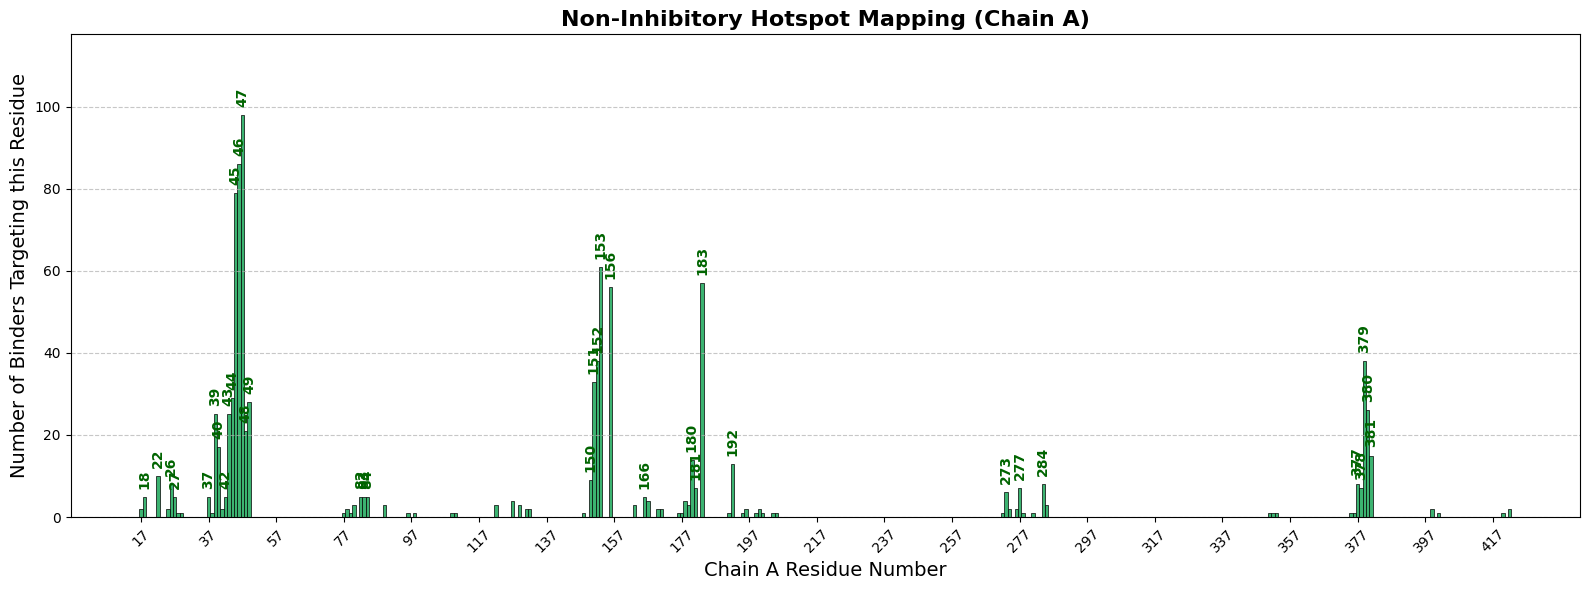


--- TOP 10 DEEPEST VALID HOTSPOTS ---
Use these residue numbers in your next RFdiffusion run:
Residue 47: 98 binders landed here
Residue 46: 86 binders landed here
Residue 45: 79 binders landed here
Residue 153: 61 binders landed here
Residue 183: 57 binders landed here
Residue 156: 56 binders landed here
Residue 379: 38 binders landed here
Residue 152: 38 binders landed here
Residue 151: 33 binders landed here
Residue 44: 29 binders landed here


In [11]:
import os
import glob
import warnings
import numpy as np
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser
from Bio import BiopythonWarning
from scipy.spatial.distance import cdist
from collections import Counter
import concurrent.futures

# Ignore messy Biopython PDB construction warnings to keep your console clean
warnings.simplefilter('ignore', BiopythonWarning)

# ==========================================
# 1. CONFIGURATION (UPDATE THESE PATHS)
# ==========================================
# Point to your main outputs folder (it will search subfolders recursively)
BASE_DIR = "/home/tonypeonio/ProteinDesignChallenge/outputs" 

# Point to your full, cleaned wild-type multimer PDB (7ut8)
WILD_TYPE_PDB = "/home/tonypeonio/ProteinDesignChallenge/pdb/cleaned_pdb/7ut8_clean.pdb"

TARGET_CHAIN = "A"
BLOCKING_CHAINS = ["B", "C", "D","E","F"] # The ghost chains to block out
DISTANCE_CUTOFF = 5.0             # Angstroms for both blocking and binding
LABEL_THRESHOLD = 5               # Minimum binders needed to label a spike on the graph

# ==========================================
# 2. DYNAMIC INTERFACE CALCULATION (GHOST CHAINS)
# ==========================================
def get_blocked_interface_residues():
    """Calculates which Chain A residues are physically touching Chains B, C, or D."""
    print(f"Loading Wild-Type PDB: {WILD_TYPE_PDB}...")
    parser = PDBParser(QUIET=True)
    try:
        structure = parser.get_structure("WT", WILD_TYPE_PDB)
    except Exception as e:
        print(f"Error loading Wild-Type PDB: {e}")
        return set()
        
    model = structure[0]
    target_atoms = []
    target_res_ids = []
    blocking_atoms = []
    
    # Gather ALL atoms (not just CA) because bulky sidechains block binders too
    for chain in model:
        if chain.id == TARGET_CHAIN:
            for residue in chain:
                if residue.id[0] == ' ': # Ignore heteroatoms
                    for atom in residue:
                        target_atoms.append(atom.coord)
                        target_res_ids.append(residue.id[1])
                        
        elif chain.id in BLOCKING_CHAINS:
            for residue in chain:
                if residue.id[0] == ' ': 
                    for atom in residue:
                        blocking_atoms.append(atom.coord)
                        
    if not target_atoms or not blocking_atoms:
        print("Warning: Could not map blocking chains. Check wild-type chain IDs.")
        return set()
        
    distances = cdist(np.array(target_atoms), np.array(blocking_atoms))
    blocked_indices = np.where(np.min(distances, axis=1) < DISTANCE_CUTOFF)[0]
    
    # Return as a set for lightning-fast lookups later
    blocked_residues = set([target_res_ids[i] for i in blocked_indices])
    print(f"--> Found {len(blocked_residues)} blocked interface residues on Chain {TARGET_CHAIN}.\n")
    return blocked_residues

# ==========================================
# 3. DYNAMIC BINDER PARSING FUNCTION
# ==========================================
def get_interacting_residues(pdb_file):
    """Dynamically finds the binder and maps its interactions with Chain A."""
    parser = PDBParser(QUIET=True)
    try:
        structure = parser.get_structure("complex", pdb_file)
    except Exception:
        return []
        
    model = structure[0]
    
    # Dynamically Identify the Binder (Shortest Chain)
    chain_lengths = {}
    for chain in model:
        ca_count = sum(1 for res in chain if 'CA' in res and res.id[0] == ' ')
        if ca_count > 0:
            chain_lengths[chain.id] = ca_count
            
    if not chain_lengths:
        return []
        
    binder_chain_id = min(chain_lengths, key=chain_lengths.get)
    
    # Guardrail: If Chain A is the shortest chain, skip this file
    if binder_chain_id == TARGET_CHAIN:
        return []
    
    target_atoms = []
    target_res_ids = []
    binder_atoms = []
    
    # We only need Alpha-Carbons (CA) for a quick structural interaction check
    for chain in model:
        if chain.id == TARGET_CHAIN:
            for residue in chain:
                if residue.id[0] == ' ' and 'CA' in residue:
                    target_atoms.append(residue['CA'].coord)
                    target_res_ids.append(residue.id[1])
        elif chain.id == binder_chain_id:
            for residue in chain:
                if residue.id[0] == ' ' and 'CA' in residue:
                    binder_atoms.append(residue['CA'].coord)
                    
    if not target_atoms or not binder_atoms:
        return []
        
    distances = cdist(np.array(target_atoms), np.array(binder_atoms))
    interacting_indices = np.where(np.min(distances, axis=1) < DISTANCE_CUTOFF)[0]
    
    return [target_res_ids[i] for i in interacting_indices]

# ==========================================
# 4. MAIN EXECUTION & PLOTTING
# ==========================================
if __name__ == '__main__':
    # Step A: Get the blocked zones
    blocked_residues = get_blocked_interface_residues()
    
    # Step B: Find all PDBs and filter for "colab"
    all_pdbs = glob.glob(os.path.join(BASE_DIR, "**", "*.pdb"), recursive=True)
    colabfold_pdbs = [f for f in all_pdbs if "colab" in f.lower()]
    
    print(f"Found {len(colabfold_pdbs)} ColabFold PDB files to analyze.")
    print("Processing across all CPU cores...")
    
    raw_interacting_residues = []
    
    # Step C: Multiprocessing extraction
    with concurrent.futures.ProcessPoolExecutor() as executor:
        results = executor.map(get_interacting_residues, colabfold_pdbs)
        
        for interactions in results:
            if interactions:
                # Deduplicate per file
                raw_interacting_residues.extend(list(set(interactions)))
    
    # Step D: Filter out the blocked residues (The Ghost Chain Fix)
    valid_interactions = [res for res in raw_interacting_residues if res not in blocked_residues]
    
    if not valid_interactions:
        print("No valid, unblocked interactions found. Check your file paths.")
    else:
        # Step E: Count and Sort Data
        counts = Counter(valid_interactions)
        residues = sorted(counts.keys())
        frequencies = [counts[res] for res in residues]
        
        # Step F: Plotting
        plt.figure(figsize=(16, 6))
        bars = plt.bar(residues, frequencies, color='mediumseagreen', width=1.0, edgecolor='black', linewidth=0.5)
        
        plt.title(f"Non-Inhibitory Hotspot Mapping (Chain {TARGET_CHAIN})", fontsize=16, fontweight='bold')
        plt.xlabel(f"Chain {TARGET_CHAIN} Residue Number", fontsize=14)
        plt.ylabel("Number of Binders Targeting this Residue", fontsize=14)
        
        # Dynamic labeling of spikes
        for res, freq in zip(residues, frequencies):
            if freq >= LABEL_THRESHOLD:
                y_offset = max(frequencies) * 0.02
                plt.text(res, freq + y_offset, str(res), 
                         ha='center', va='bottom', fontsize=10, 
                         rotation=90, fontweight='bold', color='darkgreen')
        
        plt.xticks(np.arange(min(residues), max(residues)+1, step=20), rotation=45)
        plt.ylim(0, max(frequencies) * 1.20) # 20% buffer for the text labels
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()
        
        # Step G: Print Results for RFdiffusion
        print("\n--- TOP 10 DEEPEST VALID HOTSPOTS ---")
        print("Use these residue numbers in your next RFdiffusion run:")
        for res, count in counts.most_common(10):
            print(f"Residue {res}: {count} binders landed here")